In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_1samp,ttest_ind,ttest_rel
from scipy.stats import f
from scipy.stats import levene
from   scipy.stats        import    chi2_contingency
from statsmodels.stats.power import ttest_power
%matplotlib inline 

## Project 1 (Wholesale Customer)

1.1 Use methods of descriptive statistics to summarize data. Which Region and which Channel spent the most? Which Region and which Channel spent the least?

In [3]:
wholesale_customer=pd.read_csv("Wholesale+Customers+Data (1).csv")

In [4]:
wholesale_customer.head(10)

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,1,Retail,Other,12669,9656,7561,214,2674,1338
1,2,Retail,Other,7057,9810,9568,1762,3293,1776
2,3,Retail,Other,6353,8808,7684,2405,3516,7844
3,4,Hotel,Other,13265,1196,4221,6404,507,1788
4,5,Retail,Other,22615,5410,7198,3915,1777,5185
5,6,Retail,Other,9413,8259,5126,666,1795,1451
6,7,Retail,Other,12126,3199,6975,480,3140,545
7,8,Retail,Other,7579,4956,9426,1669,3321,2566
8,9,Hotel,Other,5963,3648,6192,425,1716,750
9,10,Retail,Other,6006,11093,18881,1159,7425,2098


In [5]:
wholesale_customer["Region"].unique()

array(['Other', 'Lisbon', 'Oporto'], dtype=object)

In [6]:
wholesale_customer.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Buyer/Spender,440,NaN,NaN,NaN,220.5,127.161,1,110.75,220.5,330.25,440
Channel,440,2,Hotel,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,440,3,Other,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fresh,440,NaN,NaN,NaN,12000.3,12647.3,3,3127.75,8504,16933.8,112151
Milk,440,NaN,NaN,NaN,5796.27,7380.38,55,1533,3627,7190.25,73498
Grocery,440,NaN,NaN,NaN,7951.28,9503.16,3,2153,4755.5,10655.8,92780
Frozen,440,NaN,NaN,NaN,3071.93,4854.67,25,742.25,1526,3554.25,60869
Detergents_Paper,440,NaN,NaN,NaN,2881.49,4767.85,3,256.75,816.5,3922,40827
Delicatessen,440,NaN,NaN,NaN,1524.87,2820.11,3,408.25,965.5,1820.25,47943


In [ ]:
wholesale_customer.groupby()

In [86]:
wholesale_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Buyer/Spender     440 non-null    int64 
 1   Channel           440 non-null    object
 2   Region            440 non-null    object
 3   Fresh             440 non-null    int64 
 4   Milk              440 non-null    int64 
 5   Grocery           440 non-null    int64 
 6   Frozen            440 non-null    int64 
 7   Detergents_Paper  440 non-null    int64 
 8   Delicatessen      440 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 31.1+ KB


In [7]:
wholesale_customer.isnull().sum()

Buyer/Spender       0
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicatessen        0
dtype: int64

In [8]:
wc=wholesale_customer.copy()

In [9]:
wc["Total_Spent"]=wc["Fresh"]+wc["Milk"]+wc["Grocery"]+wc["Frozen"]+wc["Detergents_Paper"]+wc["Delicatessen"]

In [10]:
wc

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total_Spent
0,1,Retail,Other,12669,9656,7561,214,2674,1338,34112
1,2,Retail,Other,7057,9810,9568,1762,3293,1776,33266
2,3,Retail,Other,6353,8808,7684,2405,3516,7844,36610
3,4,Hotel,Other,13265,1196,4221,6404,507,1788,27381
4,5,Retail,Other,22615,5410,7198,3915,1777,5185,46100
...,...,...,...,...,...,...,...,...,...,...
435,436,Hotel,Other,29703,12051,16027,13135,182,2204,73302
436,437,Hotel,Other,39228,1431,764,4510,93,2346,48372
437,438,Retail,Other,14531,15488,30243,437,14841,1867,77407
438,439,Hotel,Other,10290,1981,2232,1038,168,2125,17834


In [11]:
wc.groupby("Channel")["Total_Spent"].sum()

Channel
Hotel     7999569
Retail    6619931
Name: Total_Spent, dtype: int64

In [12]:
wc.groupby("Region")["Total_Spent"].sum()

Region
Lisbon     2386813
Oporto     1555088
Other     10677599
Name: Total_Spent, dtype: int64

In [13]:
df=pd.crosstab(wc["Channel"],wc["Region"],wc["Total_Spent"],aggfunc=sum)
df

Region,Lisbon,Oporto,Other
Channel,,,
Hotel,1538342,719150,5742077
Retail,848471,835938,4935522


<Figure size 1080x504 with 0 Axes>

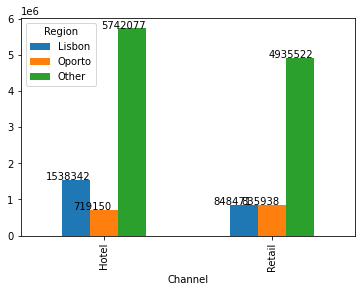

In [14]:
plt.figure(figsize=(15,7))
ax=df.plot.bar()
for p in ax.patches:
    ax.annotate("{:}".format(p.get_height()),(p.get_x()-0.1,p.get_height()+2))


1.2 There are 6 different varieties of items that are considered. Describe and comment/explain all the varieties across Region and Channel? Provide a detailed justification for your answer.

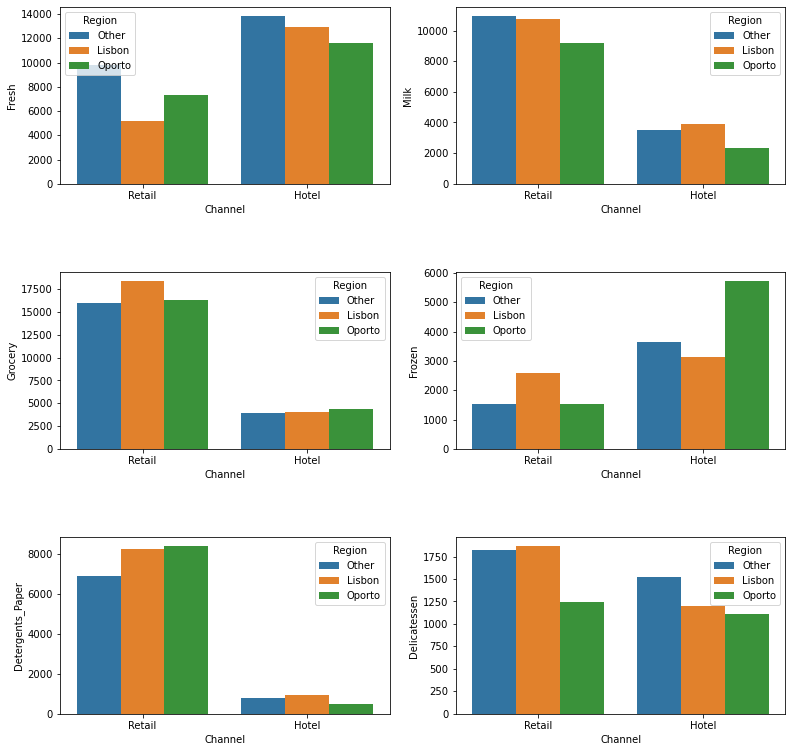

In [98]:
plt.figure(figsize=(13,13))
plt.subplot(3,2,1)
sns.barplot(x="Channel",y="Fresh",hue="Region",data=wc,ci=None)
plt.subplot(3,2,2)
sns.barplot(x="Channel",y="Milk",hue="Region",data=wc,ci=None)
plt.subplot(3,2,3)
sns.barplot(x="Channel",y="Grocery",hue="Region",data=wc,ci=None)
plt.subplot(3,2,4)
sns.barplot(x="Channel",y="Frozen",hue="Region",data=wc,ci=None)
plt.subplot(3,2,5)
sns.barplot(x="Channel",y="Detergents_Paper",hue="Region",data=wc,ci=None)
plt.subplot(3,2,6)
sns.barplot(x="Channel",y="Delicatessen",hue="Region",data=wc,ci=None)
plt.subplots_adjust(hspace=0.5,wspace=0.2)

1.3 On the basis of a descriptive measure of variability, which item shows the most inconsistent behaviour? Which items show the least inconsistent behaviour?

In [16]:
wholesale_customer_des=wholesale_customer.describe()
wholesale_customer_des

,Buyer/Spender,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,220.500000,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,127.161315,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,110.750000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,220.500000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,330.250000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,440.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [17]:



wholesale_customer_des.loc[("Co-efficeint of Variation"),:]=wholesale_customer_des.loc[("std"),:]/wholesale_customer_des.loc[("mean"),:]
wholesale_customer_des

,Buyer/Spender,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,220.500000,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,127.161315,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,110.750000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,220.500000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,330.250000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,440.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000
Co-efficeint of Variation,0.576695,1.053918,1.273299,1.195174,1.580332,1.654647,1.849407


In [18]:
# Fresh item shows least inconsistent behaviour and Delicatessen have most inconsistence behaviour 


In [19]:
wholesale_customer_des.loc[("Co-efficeint of Variation"),:]

Buyer/Spender       0.576695
Fresh               1.053918
Milk                1.273299
Grocery             1.195174
Frozen              1.580332
Detergents_Paper    1.654647
Delicatessen        1.849407
Name: Co-efficeint of Variation, dtype: float64

1.4 Are there any outliers in the data? Back up your answer with a suitable plot/technique with the help of detailed comments.

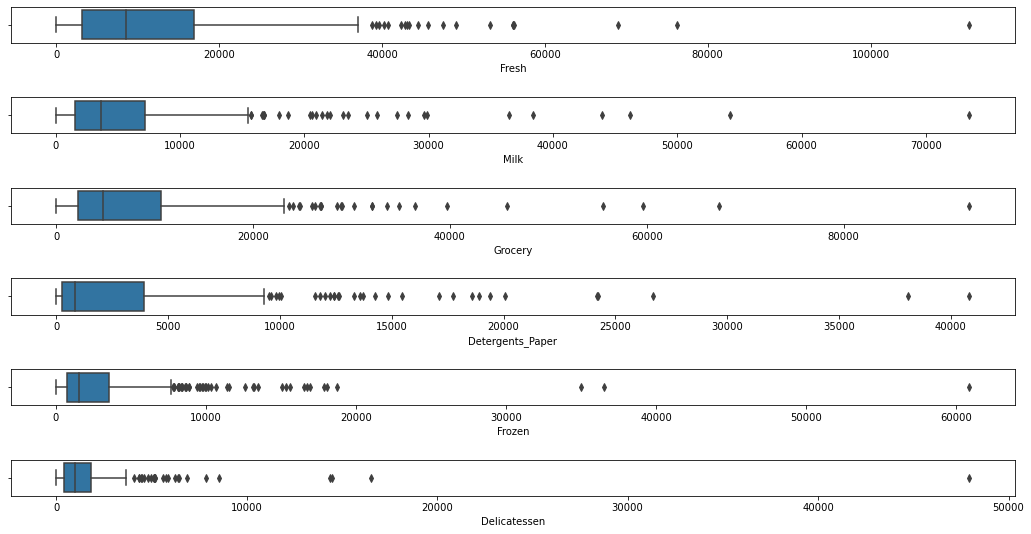

In [99]:
plt.figure(figsize=(18,9))
plt.subplot(6,1,1)
sns.boxplot(wc["Fresh"])
plt.subplot(6,1,2)
sns.boxplot(wc["Milk"])
plt.subplot(6,1,3)
sns.boxplot(wc["Grocery"])
plt.subplot(6,1,4)
sns.boxplot(wc["Detergents_Paper"])
plt.subplot(6,1,5)
sns.boxplot(wc["Frozen"])
plt.subplot(6,1,6)
sns.boxplot(wc["Delicatessen"])
plt.subplots_adjust(hspace=1.5,wspace=3)

1.5 On the basis of your analysis, what are your recommendations for the business? How can your analysis help the business to solve its problem? Answer from the business perspective

## project 2 (Student Survey CMSU)

In [21]:
student_survey=pd.read_csv("Survey-1.csv")

In [22]:
student_survey.head()

,ID,Gender,Age,Class,Major,Grad Intention,GPA,Employment,Salary,Social Networking,Satisfaction,Spending,Computer,Text Messages
0,1,Female,20,Junior,Other,Yes,2.9,Full-Time,50.0,1,3,350,Laptop,200
1,2,Male,23,Senior,Management,Yes,3.6,Part-Time,25.0,1,4,360,Laptop,50
2,3,Male,21,Junior,Other,Yes,2.5,Part-Time,45.0,2,4,600,Laptop,200
3,4,Male,21,Junior,CIS,Yes,2.5,Full-Time,40.0,4,6,600,Laptop,250
4,5,Male,23,Senior,Other,Undecided,2.8,Unemployed,40.0,2,4,500,Laptop,100


In [23]:
student_survey.isnull().sum()

ID                   0
Gender               0
Age                  0
Class                0
Major                0
Grad Intention       0
GPA                  0
Employment           0
Salary               0
Social Networking    0
Satisfaction         0
Spending             0
Computer             0
Text Messages        0
dtype: int64

2.1 For this data, construct the following contingency tables (Keep Gender as row variable)

2.1.1. Gender and Major

2.1.2. Gender and Grad Intention

2.1.3. Gender and Employment

2.1.4. Gender and Computer

In [24]:
CT1=pd.crosstab(student_survey["Gender"],student_survey["Major"])
CT1

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Female,3,3,7,4,4,3,9,0
Male,4,1,4,2,6,4,5,3


In [25]:
CT2=pd.crosstab(student_survey["Gender"],student_survey["Grad Intention"])
CT2

Grad Intention,No,Undecided,Yes
Gender,,,
Female,9,13,11
Male,3,9,17


In [26]:
CT3=pd.crosstab(student_survey["Gender"],student_survey["Employment"])
CT3

Employment,Full-Time,Part-Time,Unemployed
Gender,,,
Female,3,24,6
Male,7,19,3


In [27]:
CT4=pd.crosstab(student_survey["Gender"],student_survey["Computer"])
CT4

Computer,Desktop,Laptop,Tablet
Gender,,,
Female,2,29,2
Male,3,26,0


2.2. Assume that the sample is representative of the population of CMSU. Based on the data, answer the following question:

2.2.1. What is the probability that a randomly selected CMSU student will be male?

2.2.2. What is the probability that a randomly selected CMSU student will be female?

In [28]:
student_survey["Gender"].value_counts()

Female    33
Male      29
Name: Gender, dtype: int64

In [29]:
Total_Gender=62
Female=33
Male=29
print("The probability that a randomly choosen student will be a male is : % 1.2f" %((Male/Total_Gender)*100)+"%")

The probability that a randomly choosen student will be a male is :  46.77%


In [30]:
print("The probability that a randomly choosen student will be a male is : % 1.2f" %((Female/Total_Gender)*100)+"%")

The probability that a randomly choosen student will be a male is :  53.23%


2.3. Assume that the sample is a representative of the population of CMSU. Based on the data, answer the following question:

2.3.1 Find the conditional probability of different majors among the male students in CMSU.

2.3.2 Find the conditional probability of different majors among the female students of CMSU.

In [31]:
print(student_survey["Major"].nunique())
print(" ")
print(student_survey["Major"].unique())

8
 
['Other' 'Management' 'CIS' 'Economics/Finance' 'Undecided'
 'International Business' 'Retailing/Marketing' 'Accounting']


In [32]:
CT1

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Female,3,3,7,4,4,3,9,0
Male,4,1,4,2,6,4,5,3


In [33]:
print("Probability of a male student opting for Accounting Major is %1.2f" %((4/29)*100)+"%")
print("Probability of a male student opting for CIS Major is %1.2f" %((1/29)*100)+"%")
print("Probability of a male student opting for Economics/finance Major is %1.2f" %((4/29)*100)+"%")
print("Probability of a male student opting for International Business Major is %1.2f" %((2/29)*100)+"%")
print("Probability of a male student opting for Management Major is %1.2f" %((6/29)*100)+"%")
print("Probability of a male student opting for Other Major is %1.2f" %((4/29)*100)+"%")
print("Probability of a male student opting for Retailing/Marketing Major is %1.2f" %((5/29)*100)+"%")
print("Probability of a male student opting for Undecided Major is %1.2f" %((3/29)*100)+"%")


Probability of a male student opting for Accounting Major is 13.79%
Probability of a male student opting for CIS Major is 3.45%
Probability of a male student opting for Economics/finance Major is 13.79%
Probability of a male student opting for International Business Major is 6.90%
Probability of a male student opting for Management Major is 20.69%
Probability of a male student opting for Other Major is 13.79%
Probability of a male student opting for Retailing/Marketing Major is 17.24%
Probability of a male student opting for Undecided Major is 10.34%


In [34]:
print("Probability of a Female student opting for Accounting Major is %1.2f" %((3/33)*100)+"%")
print("Probability of a Female student opting for CIS Major is %1.2f" %((3/33)*100)+"%")
print("Probability of a Female student opting for Economics/finance Major is %1.2f" %((7/33)*100)+"%")
print("Probability of a Female student opting for International Business Major is %1.2f" %((4/33)*100)+"%")
print("Probability of a Female student opting for Management Major is %1.2f" %((4/33)*100)+"%")
print("Probability of a Female student opting for Other Major is %1.2f" %((3/33)*100)+"%")
print("Probability of a Female student opting for Retailing/Marketing Major is %1.2f" %((9/33)*100)+"%")
print("Probability of a Female student opting for Undecided Major is %1.2f" %((0/33)*100)+"%")

Probability of a Female student opting for Accounting Major is 9.09%
Probability of a Female student opting for CIS Major is 9.09%
Probability of a Female student opting for Economics/finance Major is 21.21%
Probability of a Female student opting for International Business Major is 12.12%
Probability of a Female student opting for Management Major is 12.12%
Probability of a Female student opting for Other Major is 9.09%
Probability of a Female student opting for Retailing/Marketing Major is 27.27%
Probability of a Female student opting for Undecided Major is 0.00%


2.4. Assume that the sample is a representative of the population of CMSU. Based on the data, answer the following question:

2.4.1 Find the probability That a randomly chosen student is a male and intends to graduate.

2.4.2 Find the probability that a randomly selected student is a female and does NOT have a laptop.

In [35]:
CT2

Grad Intention,No,Undecided,Yes
Gender,,,
Female,9,13,11
Male,3,9,17


In [36]:
CT4

Computer,Desktop,Laptop,Tablet
Gender,,,
Female,2,29,2
Male,3,26,0


In [37]:
student_survey["Gender"].value_counts()

Female    33
Male      29
Name: Gender, dtype: int64

In [38]:
Male=29
Total=62
probab_male=(Male/Total)
Male_Grad_Inted=(17/Male)
print("The probability That a randomly chosen student is a male and intends to graduate is %1.2f" % (Male_Grad_Inted*100)+"%")

The probability That a randomly chosen student is a male and intends to graduate is 58.62%


In [39]:
print("The probability That a randomly chosen student is a Female and does not have laptop is %1.2f" % ((4/33)*100)+"%")

The probability That a randomly chosen student is a Female and does not have laptop is 12.12%


2.5. Assume that the sample is a representative of the population of CMSU. Based on the data, answer the following question:

2.5.1 Find the probability that a randomly chosen student is a male or has a full-time employment

2.5.2 Find the conditional probability that given a female student is randomly chosen, she is majoring in international business or management.

In [40]:
CT3

Employment,Full-Time,Part-Time,Unemployed
Gender,,,
Female,3,24,6
Male,7,19,3


In [41]:
Probab_male=Male/Total
Probab_Full_emp=7/Male
print("the probability that a randomly chosen student is a male or has a full-time employment is %1.2f" %((Probab_male+Probab_Full_emp)*100)+"%")

the probability that a randomly chosen student is a male or has a full-time employment is 70.91%


In [42]:
prob_female_Interbusi=4/33
prob_female_manage=4/33
print("the conditional probability that given a female student is randomly chosen, she is majoring in international business or management. %1.2f" %((prob_female_Interbusi+prob_female_manage)*100)+"%")

the conditional probability that given a female student is randomly chosen, she is majoring in international business or management. 24.24%


2.6 Construct a contingency table of Gender and Intent to Graduate at 2 levels (Yes/No). The Undecided students are not considered now and the table is a 2x2 table. Do you think graduate intention and being female are independent events?


In [111]:
CT22=CT2.copy()

In [114]:
CT22.drop("Undecided",axis=1)

Grad Intention,No,Yes
Gender,,
Female,9,11
Male,3,17


In [125]:
CT22.drop(["Grand Total"],axis=0)

Grad Intention,No,Undecided,Yes,Total
Gender,,,,
Female,9,13,11,20
Male,3,9,17,20


2.7 Note that there are four numerical (continuous) variables in the data set, GPA, Salary, Spending and Text Messages. Answer the following questions based on the data

2.7.1 If a student is chosen randomly, what is the probability that his/her GPA is less than 3?

2.7.2 Find conditional probability that a randomly selected male earns 50 or more. Find conditional probability that a randomly selected female earns 50 or more.

In [45]:
student_survey[student_survey["GPA"]<3.0]["Gender"].value_counts()

Male      9
Female    8
Name: Gender, dtype: int64

In [131]:
pd.crosstab(student_survey["Gender"],student_survey["GPA"],margins=True)

GPA,2.3,2.4,2.5,2.6,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.6,3.7,3.8,3.9,All
Gender,,,,,,,,,,,,,,,,,
Female,1,1,2,0,1,3,5,2,4,3,2,4,1,2,1,1,33
Male,0,0,4,2,2,1,2,5,2,2,5,2,2,0,0,0,29
All,1,1,6,2,3,4,7,7,6,5,7,6,3,2,1,1,62


In [46]:
Total_students_GPA_less_than_3_is=17
Total_students=62
print("If a student is chosen randomly,the probability that his/her GPA is less than 3 is %1.2f" % ((Total_students_GPA_less_than_3_is/Total_students)*100)+"%")

If a student is chosen randomly,the probability that his/her GPA is less than 3 is 27.42%


In [47]:
student_survey[student_survey["Salary"]>=50]["Gender"].value_counts()

Female    18
Male      14
Name: Gender, dtype: int64

In [48]:
print("The Probability that a randomly selected male earns 50 or more is %1.2f" % ((14/29)*100)+"%")

The Probability that a randomly selected male earns 50 or more is 48.28%


In [49]:
print("The Probability that a randomly selected female earns 50 or more is %1.2f" % ((18/33)*100)+"%")

The Probability that a randomly selected female earns 50 or more is 54.55%


2.8.1 Note that there are four numerical (continuous) variables in the data set, GPA, Salary, Spending and Text Messages. For each of them comment whether they follow a normal distribution.

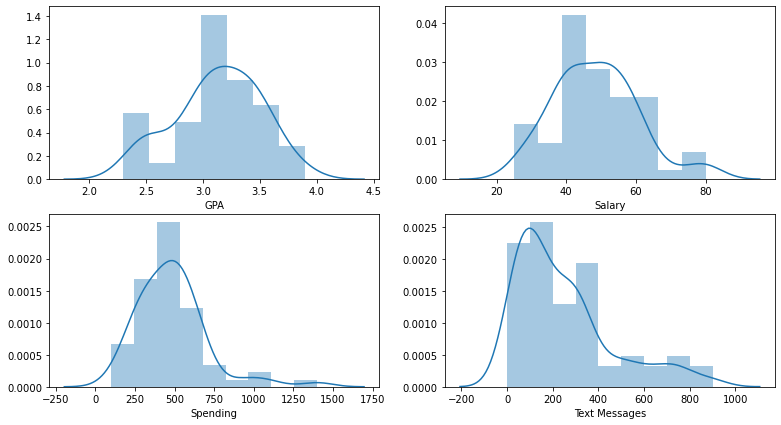

In [50]:
plt.figure(figsize=(13,7))
plt.subplot(2,2,1)
sns.distplot(student_survey["GPA"],kde=True)
plt.subplot(2,2,2)
sns.distplot(student_survey["Salary"],kde=True)
plt.subplot(2,2,3)
sns.distplot(student_survey["Spending"],kde=True)
plt.subplot(2,2,4)
sns.distplot(student_survey["Text Messages"],kde=True)

In [133]:
print(stats.shapiro(student_survey["GPA"]))
print(stats.shapiro(student_survey["Salary"]))
print(stats.shapiro(student_survey["Spending"]))
print(stats.shapiro(student_survey["Text Messages"]))


ShapiroResult(statistic=0.9685361981391907, pvalue=0.11204058676958084)
ShapiroResult(statistic=0.9565856456756592, pvalue=0.028000956401228905)
ShapiroResult(statistic=0.8777452111244202, pvalue=1.6854661225806922e-05)
ShapiroResult(statistic=0.8594191074371338, pvalue=4.324040673964191e-06)


In [135]:
alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if 0.11204058676958084 < alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance so the data is normally distributed') 


Level of significance: 0.05
We have no evidence to reject the null hypothesis since p value > Level of significance so the data is normally distributed


In [136]:
alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if 0.028000956401228905 < alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance so the data is normally distributed') 


Level of significance: 0.05
We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed


In [137]:
alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if 1.6854661225806922e-05 < alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance so the data is normally distributed') 


Level of significance: 0.05
We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed


In [138]:
alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if 4.324040673964191e-06 < alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance so the data is normally distributed') 


Level of significance: 0.05
We have evidence to reject the null hypothesis since p value < Level of significance so data is not normally distributed


## Project 3 (A&B Shingles)

In [51]:
abs=pd.read_csv("A+&+B+shingles.csv")

In [52]:
abs.shape

(36, 2)

In [53]:
abs.head(2)

,A,B
0,0.44,0.14
1,0.61,0.15


3.1 Do you think there is evidence that means moisture contents in both types of shingles are within the permissible limits? State your conclusions clearly showing all steps.

In [54]:
#Null Hypothesis H0 : Mean Moisture <=0.35
#Alternate Hypothesis H1 : Mean Moisture >0.35
# Here, The test is right sided test. We have to find out the T_stat value and p_value for the right sides test and its is single one smaple test.

In [55]:
tstat_value,p_value=stats.ttest_1samp(abs["A"],0.35)

In [56]:
tstat_value


-1.4735046253382782

In [57]:
p=p_value/2
p

0.07477633144907513

In [58]:
# here we consider the significane value (Aplha) is 0.05
# p_value < 0.05 => alternative hypothesis:

alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if p < alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance') 

print ("Our one-sample tstat_value p=", p)

Level of significance: 0.05
We have no evidence to reject the null hypothesis since p value > Level of significance
Our one-sample tstat_value p= 0.07477633144907513


In [59]:
# from the above output we can say that the mean moisture for A shingles have in permissable limits i.e,less than 0.35 moisture content.

In [60]:
# for B type:
#Null Hypothesis H0 : Mean Moisture <=0.35
#Alternate Hypothesis H1 : Mean Moisture >0.35
# Here, The test is right sided test. We have to find out the T_stat value and p_value for the right sides test and its is single one smaple test.

In [61]:
Btstat_value,Bp_value=stats.ttest_1samp(abs["B"],0.35,nan_policy="omit")

In [62]:
Btstat_value

-3.1003313069986995

In [63]:
B_P=Bp_value/2
B_P

0.0020904774003191826

In [64]:
# here we consider the significane value (Aplha) is 0.05
# p_value < 0.05 => alternative hypothesis:

alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if B_P < alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance') 

print ("Our one-sample Btstat_value B_P=", B_P)

Level of significance: 0.05
We have evidence to reject the null hypothesis since p value < Level of significance
Our one-sample Btstat_value B_P= 0.0020904774003191826


In [65]:
# from the above output we can say that the mean moisture for B shingles have is not in permissable limits i.e,the mositure content is greater tha, 0.35.

In [66]:
print("There is evidence that means moisture contents in A Shingles are within the permissible limits and means moisture contents B Shingles are not in the permissible limits") 

There is evidence that means moisture contents in A Shingles are within the permissible limits and means moisture contents B Shingles are not in the permissible limits


3.2 Do you think that the population mean for shingles A and B are equal? Form the hypothesis and conduct the test of the hypothesis. What assumption do you need to check before the test for equality of means is performed?

In [67]:
stats.shapiro(abs["A"])

ShapiroResult(statistic=0.9375598430633545, pvalue=0.042670514434576035)

In [77]:
stats.shapiro(abs["B"])

ShapiroResult(statistic=nan, pvalue=1.0)

In [85]:
stats.levene(abs["A"],abs["B"])

LeveneResult(statistic=nan, pvalue=nan)

In [68]:
abs["A"].mean()

0.3166666666666666

In [69]:
abs["B"].mean()

0.2735483870967742

In [70]:
if abs["A"].mean()==abs["B"].mean():
    print("The population mean for shingles A and B are equal")
else:
    print("The population mean for shingles A and B are not equal")

The population mean for shingles A and B are not equal


In [71]:
#Null Hypothesis H0 : Mean Moisture <=0.35
#Alternate Hypothesis H1 : Mean Moisture >0.35
# Here, The test is two sided test. 

In [72]:
ABtstat_value,ABp_value=stats.ttest_ind(abs["A"],abs["B"],equal_var=True,nan_policy="omit")

In [73]:
ABtstat_value

1.2896282719661123

In [74]:
ABp_value

0.2017496571835306

In [75]:
# here we consider the significane value (Aplha) is 0.05
# p_value < 0.05 => alternative hypothesis:

alpha_value = 0.05 # Level of significance
print('Level of significance: %.2f' %alpha_value)
if ABp_value< alpha_value: 
    print('We have evidence to reject the null hypothesis since p value < Level of significance')
else:
    print('We have no evidence to reject the null hypothesis since p value > Level of significance') 

print ("Our Two-sample ABtstat_value ABp_value=", ABp_value)

Level of significance: 0.05
We have no evidence to reject the null hypothesis since p value > Level of significance
Our one-sample ABtstat_value ABp_value= 0.2017496571835306


In [76]:
#from the above conlusion we can say that, the mean moisture for the A and B shingles are with in the permissbale limit. 